##  Proposta de solução com modelo preditivo

### 🎯 Estratégia adotada  
Foi adotada uma abordagem de **regressão**, com o objetivo de prever o valor do NPS em escala contínua (0 a 10), utilizando dados operacionais como entrega, atendimento e características do pedido.

---

### ⚙️ Justificativa técnica  
A escolha pela regressão se deve ao fato de o NPS ser uma variável numérica contínua.  
Essa abordagem permite capturar com maior precisão as variações na satisfação do cliente, mantendo um nível mais alto de detalhamento na previsão.

---

### 💼 Justificativa de negócio  
A previsão contínua do NPS possibilita identificar, com antecedência, clientes com maior risco de insatisfação.

Com isso, a empresa pode:
- Atuar de forma preventiva na jornada do cliente  
- Priorizar atendimentos mais críticos  
- Reduzir impactos negativos na experiência  
- Melhorar retenção e fidelização  

---

### 🔄 Abordagem alternativa  
Uma alternativa seria a utilização de modelos de **classificação**, categorizando os clientes em promotores, neutros e detratores.

Apesar de mais simples, essa abordagem reduz a granularidade da informação, podendo limitar a capacidade de análise e priorização.

---

### ✅ Conclusão  
A utilização de regressão se mostra mais adequada ao problema, pois permite previsões mais detalhadas e apoia decisões mais estratégicas e proativas na gestão da experiência do cliente.

# 1. Importando a Base de Dados

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_palette('Accent')
sns.set_theme(style='darkgrid')

In [33]:
# Fazendo a leitura da base de dados
dados = pd.read_csv('../data/NPS.csv')
dados.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 2. Análises Preliminares


### 📌 Verificação da estrutura do dataset
Foi utilizado o método `dados.info()` para entender a estrutura geral do dataset, incluindo:
- Tipos de dados de cada coluna  
- Quantidade de registros  
- Presença de valores nulos  


In [34]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

### 🌎 Análise da variável categórica
A coluna `customer_region` foi analisada por ser a única variável categórica do dataset.

- `unique()` foi utilizado para identificar as regiões presentes  
- `value_counts()` para verificar a distribuição dos clientes por região  

Essa análise ajuda a entender a representatividade geográfica dos dados.


In [35]:
# Pegando os Dados únicos da coluna "customer_region"
dados['customer_region'].unique()

<StringArray>
['Nordeste', 'Sul', 'Centro-Oeste', 'Norte', 'Sudeste']
Length: 5, dtype: str

In [36]:
# Pegando a distribuição de cada região
dados['customer_region'].value_counts()

customer_region
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468
Name: count, dtype: int64

### ⚠️ Verificação de dados nulos
Foi realizada a soma total de valores nulos no dataset utilizando `isnull().sum().sum()`.

Resultado:  
✔️ Não há dados nulos no dataset  

In [37]:
print(f'Total de Dados Nulos no Dataset : {dados.isnull().sum().sum()}')

Total de Dados Nulos no Dataset : 0


### 🔁 Verificação de dados duplicados
Foi feita a verificação de registros duplicados com `dados.duplicated().sum()`.

Resultado:  
✔️ Não há registros duplicados  

In [38]:
print(f'Total de Dados Duplicados : {dados.duplicated().sum()}')

Total de Dados Duplicados : 0


### 📊 Estatística descritiva
Foi utilizada a função `describe()` para obter um resumo estatístico das variáveis numéricas, incluindo:

- Média  
- Desvio padrão  
- Valores mínimos e máximos  
- Quartis (25%, 50% e 75%)  

In [39]:
dados.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


# 3. Análises Gráficas

### 📦 Boxplot do NPS
Foi utilizado um boxplot para visualizar a distribuição do NPS e identificar possíveis outliers.

Observações:
- Os valores estão distribuídos entre 0 e 10  
- Não há presença significativa de outliers  
- A mediana está próxima de 4, indicando uma tendência a avaliações mais baixas

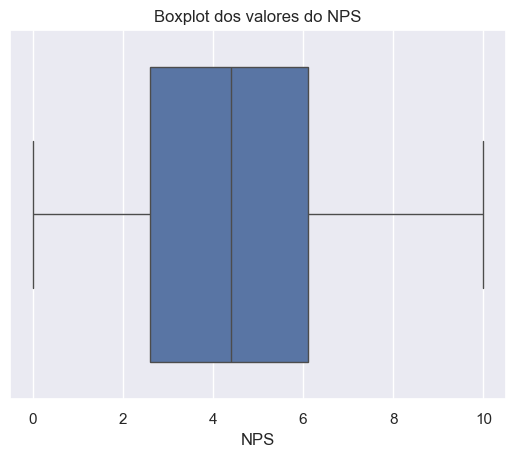

In [40]:
sns.boxplot(data=dados, x='nps_score')
plt.title('Boxplot dos valores do NPS')
plt.xlabel('NPS')
plt.show()

### 📈 Estatística descritiva do NPS
Foi analisado o resumo estatístico da variável `nps_score`.

Principais pontos:
- Média: aproximadamente 4.38  
- Mediana: aproximadamente 4.40  
- Desvio padrão: 2.51  
- Intervalo: de 0 a 10  

Isso indica que a maior parte das avaliações está concentrada em níveis mais baixos de satisfação.


In [41]:
dados['nps_score'].describe().round(2)

count    2500.00
mean        4.38
std         2.51
min         0.00
25%         2.60
50%         4.40
75%         6.10
max        10.00
Name: nps_score, dtype: float64

### 📉 Histograma do NPS
O histograma foi utilizado para visualizar a frequência das notas de NPS.

Observações:
- A distribuição apresenta maior concentração entre valores baixos e médios  
- Há menor frequência de notas altas (promotores)  
- Indica uma predominância de clientes menos satisfeitos  

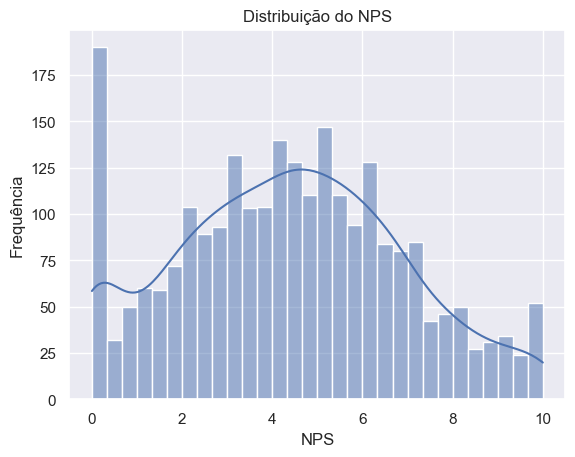

In [42]:
sns.histplot(data=dados, x='nps_score', bins=30, kde=True)
plt.title('Distribuição do NPS')
plt.xlabel('NPS')
plt.ylabel('Frequência')
plt.show()

## Análise Gráfica da Relação entre as Variáveis


In [43]:
# pegando a correlação apenas dos dados numéricos
correlacao = dados.select_dtypes(include=[np.number]).corr().round(2)

### 🔥 Mapa de correlação (Heatmap)
Foi gerado um mapa de correlação entre as variáveis numéricas para identificar relações lineares entre elas.


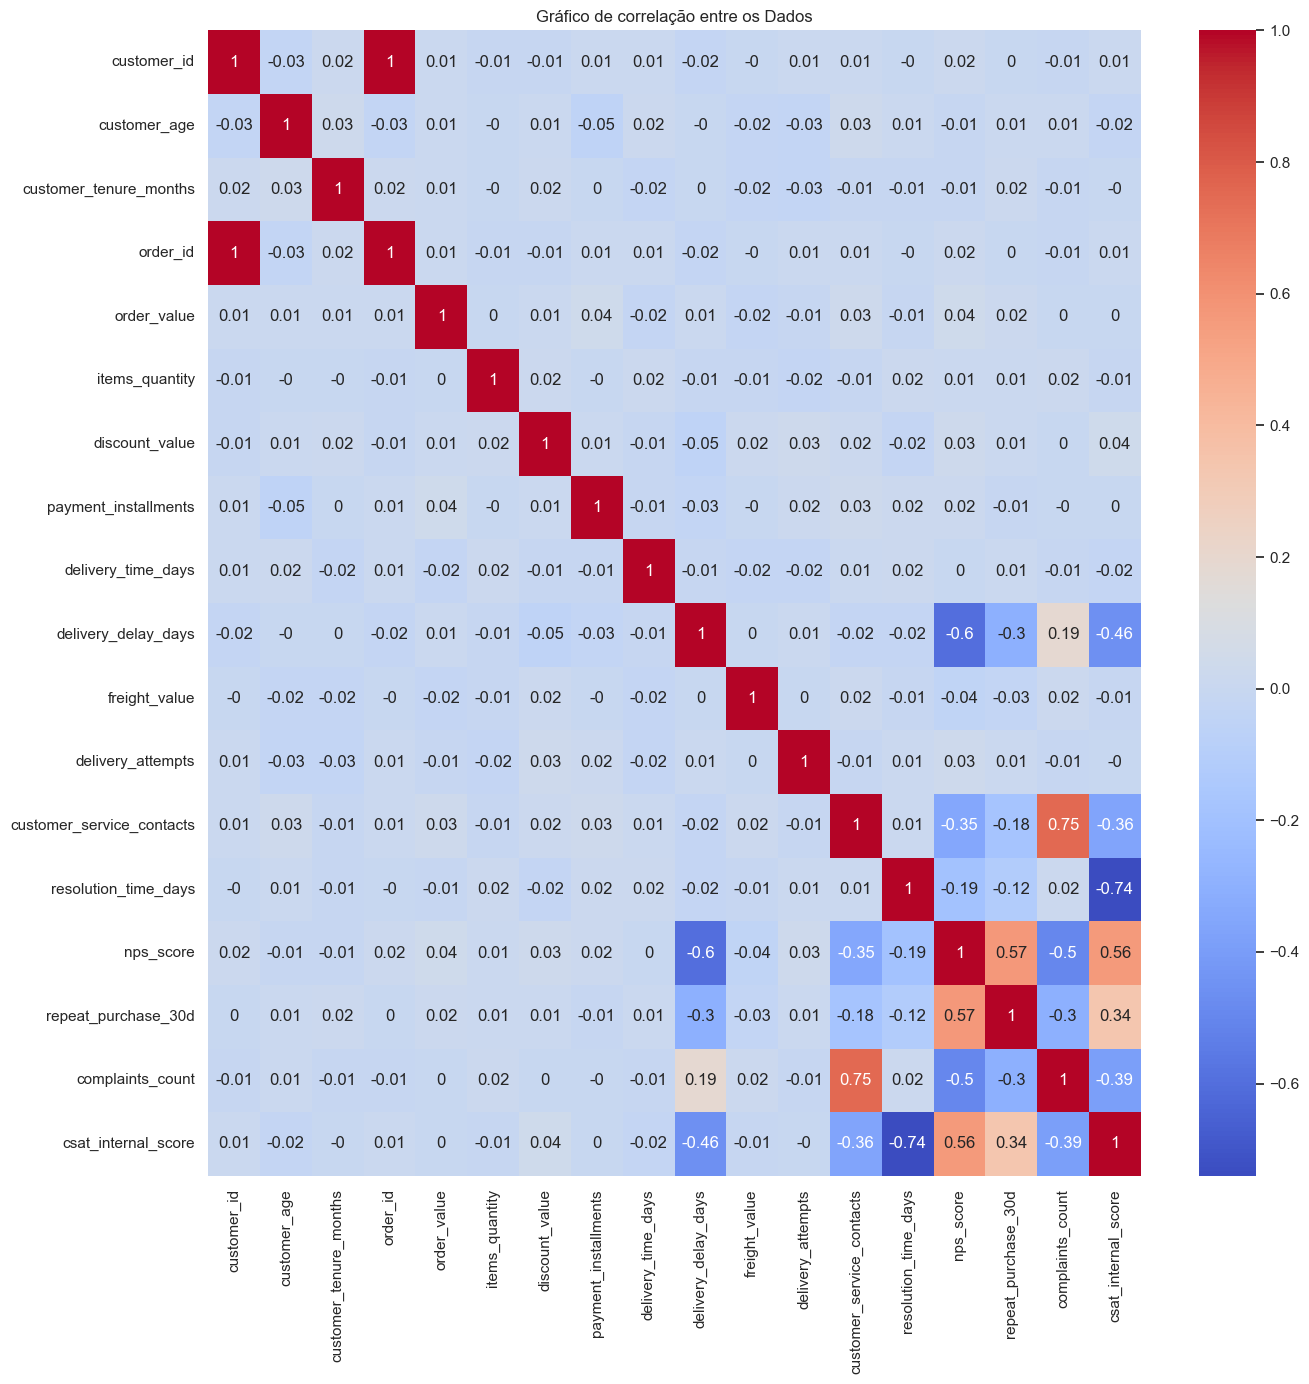

In [44]:
ax = plt.subplots(figsize=(14,14))
ax = sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title('Gráfico de correlação entre os Dados')
plt.tight_layout()
plt.show()

Pegando os valores numéricos com mair correlação : "delivery_delay_days", "customer_service_contacts", "repeat_purchase_30d", "complaints_count", "csat_internal_score"

### 📉 Relação das variáveis com o NPS (Pairplot)
Foi utilizado um gráfico de dispersão (pairplot) para analisar a relação entre o NPS e algumas variáveis relevantes.

Principais insights:

- **delivery_delay_days:**  
  Apresenta relação negativa com o NPS — quanto maior o atraso, menor a satisfação  

- **customer_service_contacts:**  
  Clientes com mais contatos com o atendimento tendem a ter NPS mais baixo  

- **complaints_count:**  
  Forte relação negativa — mais reclamações estão associadas a menor satisfação  

- **csat_internal_score:**  
  Relação positiva clara — quanto maior o score interno, maior o NPS  

- **repeat_purchase_30d:**  
  Clientes que realizam recompra tendem a apresentar NPS mais alto  


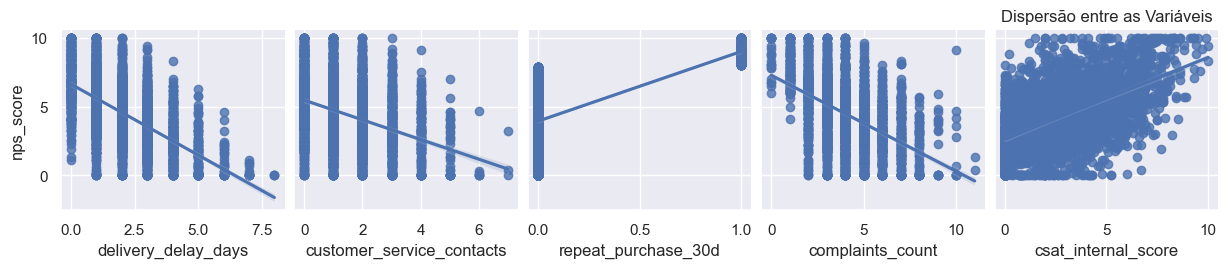

In [45]:
sns.pairplot(data=dados, y_vars='nps_score', x_vars=['delivery_delay_days','customer_service_contacts','repeat_purchase_30d', 'complaints_count', 'csat_internal_score'], kind='reg')
plt.title('Dispersão entre as Variáveis')
plt.show()

## Criação de Categorias e Amostragem Estratificada

### 📊 Distribuição do NPS
Inicialmente, foi analisada a distribuição da variável `nps_score` por meio de um histograma.

Observações:
- Os valores estão distribuídos entre 0 e 10  
- Há maior concentração de clientes em faixas mais baixas e intermediárias  
- Indica predominância de clientes neutros e detratores  

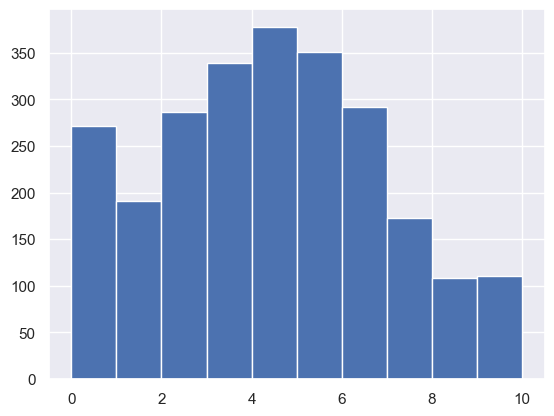

In [46]:
dados['nps_score'].hist()
plt.show()

### 🏷️ Criação das categorias de NPS
Para viabilizar a estratificação dos dados, o NPS foi segmentado em categorias:

- **Detratores:** 0 a 6  
- **Neutros:** 6 a 8  
- **Promotores:** 8 a 10  

Essa categorização permite representar diferentes perfis de satisfação dos clientes.

In [47]:
dados['classe'] = pd.cut(dados['nps_score'],
                         bins=[-1, 6., 8., np.inf],
                         labels=['Detratores', 'Neutros', 'Promotores'])

In [48]:
dados['classe'].value_counts()

classe
Detratores    1851
Neutros        448
Promotores     201
Name: count, dtype: int64

### ⚖️ Amostragem estratificada
A divisão entre treino e teste foi realizada de forma estratificada, utilizando a variável categórica criada.

Objetivo:
- Manter a mesma proporção de clientes (detratores, neutros e promotores) nos conjuntos de treino e teste  
- Evitar viés na modelagem  
- Garantir melhor capacidade de generalização do modelo  

In [49]:
X = dados.drop('nps_score',axis=1)
y = dados['nps_score']

In [50]:
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, stratify=dados['classe'], test_size=0.2, random_state=123)

### ✅ Validação da estratificação
Foi feita a comparação das proporções entre o dataset original e o conjunto de treino.

Resultado:
- As distribuições são praticamente idênticas  
- Confirma que a estratificação foi aplicada corretamente  

In [51]:
x_treino['classe'].value_counts(normalize=True)

classe
Detratores    0.7405
Neutros       0.1790
Promotores    0.0805
Name: proportion, dtype: float64

In [52]:
dados['classe'].value_counts(normalize=True)

classe
Detratores    0.7404
Neutros       0.1792
Promotores    0.0804
Name: proportion, dtype: float64

### 🧹 Limpeza dos dados
Após a divisão, foram removidas variáveis que não agregam valor ao modelo:

- `classe` (usada apenas para estratificação)  
- `customer_id` e `order_id` (identificadores sem relevância preditiva)  

In [53]:
x_treino.drop(['classe', 'customer_id','order_id'], axis=1, inplace=True)
x_teste.drop(['classe', 'customer_id','order_id'], axis=1, inplace=True)

## 3.  ⚙️ Pré-processamento dos dados

### 🔧 Preparação dos dados
Foi construído um pipeline de pré-processamento utilizando o Scikit-learn, permitindo aplicar diferentes transformações de forma organizada e consistente.

As variáveis numéricas foram padronizadas com o uso do **StandardScaler**, garantindo que todas estejam na mesma escala e evitando que algumas tenham influência desproporcional no modelo. Já a variável categórica `customer_region` foi transformada por meio de **One-Hot Encoding**, convertendo suas categorias em formato numérico.

---

### 🔀 Aplicação do pipeline
As transformações foram integradas com o uso do **ColumnTransformer**, permitindo tratar variáveis numéricas e categóricas de forma simultânea.

O pipeline foi ajustado apenas nos dados de treino e aplicado ao conjunto de teste, evitando vazamento de dados e garantindo uma avaliação mais realista da performance do modelo.

---

### 📊 Estrutura final dos dados
Após o pré-processamento, os dados foram convertidos novamente em DataFrame, facilitando a visualização e interpretação das variáveis utilizadas na modelagem.


In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [55]:
num_pipeline = Pipeline([
    ('std_scaler', StandardScaler())
])

In [56]:
numericos = ['customer_age', 'customer_tenure_months','order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days',
             'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'repeat_purchase_30d', 'complaints_count','csat_internal_score']
categoricos = ['customer_region']

In [57]:
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, numericos),
    ("cat", OneHotEncoder(sparse_output=False), categoricos)
])

In [58]:
x_treino_tratado = full_pipeline.fit_transform(x_treino)
x_teste_tratado = full_pipeline.transform(x_teste)

In [59]:
num_cols = list(numericos)
cat_cols = full_pipeline.named_transformers_['cat'].get_feature_names_out(categoricos)

In [60]:
X_treino = pd.DataFrame(x_treino_tratado, columns=num_cols + list(cat_cols))
X_teste = pd.DataFrame(x_teste_tratado, columns=num_cols + list(cat_cols))

* Resultado Pré-Processamento

In [61]:
x_treino.head()

,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,repeat_purchase_30d,complaints_count,csat_internal_score
1769,38,Sudeste,117,569.52,5,0.14,11,5,2,33.96,2,0,4,0,3,4.9
1398,49,Nordeste,7,94.23,1,21.63,3,7,1,58.30,3,1,11,0,3,0.8
2056,25,Norte,33,996.42,3,9.60,8,4,4,39.62,2,4,6,0,8,0.0
1970,31,Norte,4,885.10,6,11.54,1,8,2,55.21,3,0,4,0,1,5.2
1208,25,Sudeste,22,549.08,1,27.15,7,13,1,13.41,2,3,9,0,5,0.7


## 4. Modelos de Machine Learning

## Regressão Linear com StatsModels

In [62]:
import statsmodels.api as sm

In [63]:
X_treino = X_treino.reset_index(drop=True)
y_treino = y_treino.reset_index(drop=True)

In [64]:
x_treino_com_constante = sm.add_constant(X_treino)

modelo_stats_models = sm.OLS(y_treino, x_treino_com_constante).fit()

### 🔎 Principais insights
A análise dos coeficientes permite identificar quais variáveis têm maior impacto no NPS:

- **delivery_delay_days:** impacto negativo relevante — atrasos reduzem significativamente a satisfação  
- **customer_service_contacts:** relação negativa — mais contatos indicam problemas na jornada  
- **complaints_count:** forte impacto negativo — aumento de reclamações está associado a menor NPS  
- **csat_internal_score:** impacto positivo — maior satisfação interna está relacionada a melhores avaliações  

Esses fatores reforçam que a experiência operacional (entrega e atendimento) é determinante para a satisfação do cliente.


In [65]:
print(modelo_stats_models.summary())

                            OLS Regression Results                            
Dep. Variable:              nps_score   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     193.0
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        08:46:36   Log-Likelihood:                -3635.2
No. Observations:                2000   AIC:                             7310.
Df Residuals:                    1980   BIC:                             7422.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

## Modelo de Regressão Linear



In [66]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [67]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_treino, y_treino)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 📈 Métricas de desempenho
Para avaliar o modelo, foram utilizadas as seguintes métricas:

- **R² (coeficiente de determinação):** indica o quanto o modelo consegue explicar a variação do NPS  
- **MAE (erro absoluto médio):** média do erro em pontos de NPS  
- **RMSE (raiz do erro quadrático médio):** penaliza erros maiores, indicando a variabilidade dos erros  

---

In [68]:
print('Métricas Modelo Regressão Linear Treino')
print(f'R² : {metrics.r2_score(y_treino, modelo_lr.predict(X_treino))}')
print(f'MAE: {metrics.mean_absolute_error(y_treino, modelo_lr.predict(X_treino))}')
print(f'RMSE: {np.sqrt(metrics.mean_squared_error(y_treino, modelo_lr.predict(X_treino)))}')

print('-'*50)

print('Métricas Modelo Regressão Linear Teste')
print(f'R² : {metrics.r2_score(y_teste, modelo_lr.predict(X_teste))}')
print(f'MAE: {metrics.mean_absolute_error(y_teste, modelo_lr.predict(X_teste))}')
print(f'RMSE: {np.sqrt(metrics.mean_squared_error(y_teste, modelo_lr.predict(X_teste)))}')

Métricas Modelo Regressão Linear Treino
R² : 0.649340532305396
MAE: 1.188230997408084
RMSE: 1.489815616005221
--------------------------------------------------
Métricas Modelo Regressão Linear Teste
R² : 0.6382830443308
MAE: 1.1842943804356119
RMSE: 1.494483778426434


## Visualização dos Resultados do Modelo

### 📉 Real vs. Previsto
Foi gerado um gráfico comparando os valores reais de NPS com os valores previstos pelo modelo, permitindo avaliar visualmente sua performance.

---

### 📈 Interpretação
Observa-se uma relação linear positiva, indicando que o modelo acompanha a tendência dos dados.

A maioria dos pontos se concentra próxima à linha de tendência, sugerindo bom ajuste, embora ainda exista certa dispersão, principalmente nos valores extremos.

---


In [69]:
y_teste_previsto = modelo_lr.predict(X_teste)

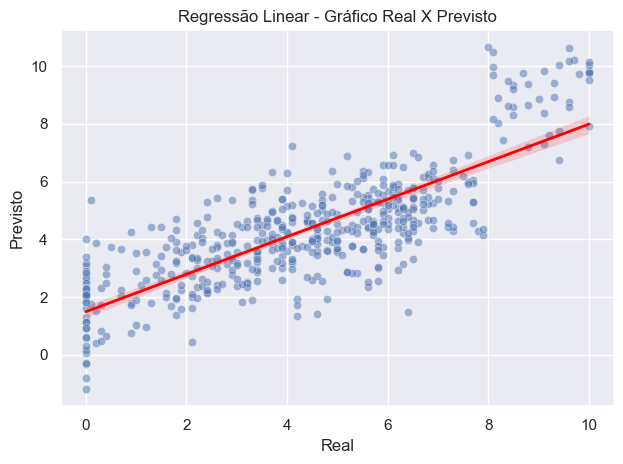

In [70]:
sns.scatterplot(x=y_teste, y=y_teste_previsto, alpha=0.5)

sns.regplot(
        x=y_teste,
        y=y_teste_previsto,
        scatter=False,            # não recria os pontos
        color="red",              # linha de tendência em vermelho
        line_kws={"linewidth": 2} # deixa a linha mais grossa
    )

plt.title("Regressão Linear - Gráfico Real X Previsto")
plt.xlabel("Real")
plt.ylabel("Previsto")
plt.tight_layout()
plt.show()

## 📉 Análise dos resíduos

### 🔎 Avaliação dos erros
Foi gerado um gráfico de resíduos para analisar a diferença entre os valores reais e previstos pelo modelo.

---

### 📈 Interpretação
Os resíduos estão distribuídos de forma relativamente aleatória em torno de zero, indicando que o modelo não apresenta viés evidente.

Observa-se uma leve dispersão, sugerindo variação nos erros, principalmente em alguns pontos extremos.


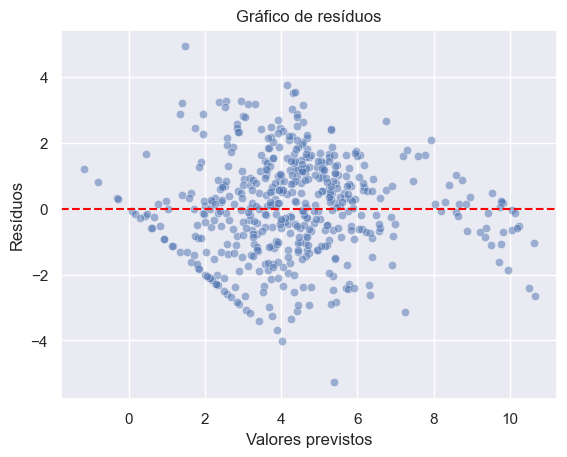

In [71]:
residuo = y_teste - y_teste_previsto

sns.scatterplot(x=y_teste_previsto, y=residuo, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores previstos")
plt.ylabel("Resíduos")
plt.title("Gráfico de resíduos")
plt.show()

## 💼 Aplicação da solução na prática

A solução desenvolvida permite à empresa **antecipar o nível de satisfação dos clientes**, estimando o NPS a partir de dados operacionais ao longo da jornada.

Com isso, deixa de ser necessário aguardar o fim da experiência para identificar problemas, possibilitando uma atuação mais **proativa e orientada por dados**.

O modelo também contribui para identificar, de forma clara, **quais fatores têm maior impacto na satisfação do cliente**, apoiando decisões estratégicas em áreas como logística, atendimento e experiência do usuário.

Além disso, a capacidade de prever o NPS permite reconhecer clientes com maior risco de insatisfação, viabilizando **ações preventivas**, como ajustes no processo, priorização de atendimentos e intervenções direcionadas.

Dessa forma, a solução fortalece a tomada de decisão baseada em dados e contribui diretamente para **melhoria contínua da experiência do cliente, aumento da fidelização e ganho de competitividade no e-commerce**.